In [ ]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

torch.manual_seed(42)
np.random.seed(42)

Device: cpu


In [ ]:
import kagglehub
path = kagglehub.dataset_download("chethuhn/network-intrusion-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'network-intrusion-dataset' dataset.
Path to dataset files: /kaggle/input/network-intrusion-dataset


In [ ]:
import os
import glob

csv_files = glob.glob(path + "/*.csv")

print("Number of CSV files found:", len(csv_files))
for f in csv_files:
    print(os.path.basename(f))

Number of CSV files found: 8
Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Tuesday-WorkingHours.pcap_ISCX.csv
Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Monday-WorkingHours.pcap_ISCX.csv
Friday-WorkingHours-Morning.pcap_ISCX.csv
Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Wednesday-workingHours.pcap_ISCX.csv


In [ ]:
wed_file = os.path.join(path, "Wednesday-workingHours.pcap_ISCX.csv")

df = pd.read_csv(wed_file)
df.columns = df.columns.str.strip()

print("Using file:", wed_file)
print("Wednesday_dataset shape:", df.shape)
print(df["Label"].value_counts())

Using file: /kaggle/input/network-intrusion-dataset/Wednesday-workingHours.pcap_ISCX.csv
Wednesday_dataset shape: (692703, 79)
Label
BENIGN              440031
DoS Hulk            231073
DoS GoldenEye        10293
DoS slowloris         5796
DoS Slowhttptest      5499
Heartbleed              11
Name: count, dtype: int64


In [ ]:
#keeping Dos labels
dos_label = [label for label in df["Label"].unique() if "DoS" in label or "DDoS" in label]
sel_labels = ["BENIGN"] + dos_label

print("Selected labels:", sel_labels)

df = df[df["Label"].isin(sel_labels)].copy()

print("Filtered shape:", df.shape)
print(df["Label"].value_counts())

Selected labels: ['BENIGN', 'DoS slowloris', 'DoS Slowhttptest', 'DoS Hulk', 'DoS GoldenEye']
Filtered shape: (692692, 79)
Label
BENIGN              440031
DoS Hulk            231073
DoS GoldenEye        10293
DoS slowloris         5796
DoS Slowhttptest      5499
Name: count, dtype: int64


(691395, 78)
Remaining labels:


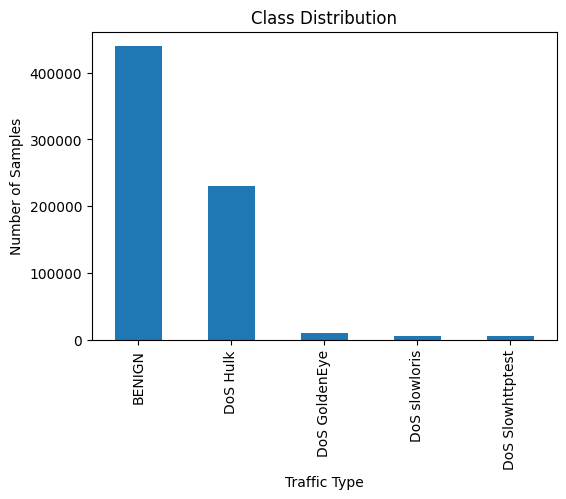

No of features: 78


In [ ]:
# Removing non-feature columns
drop_cols = ["Label"]
if "source_file" in df.columns:
    drop_cols.append("source_file")

X = df.drop(columns=drop_cols)
y = df["Label"]

#converting to numeric
X = X.apply(pd.to_numeric, errors="coerce")

X = X.replace([np.inf, -np.inf], np.nan)
X = X.dropna()

# Matching labels after dropping the rows
y = y.loc[X.index]

print(X.shape)
print("Remaining labels:")
plt.figure(figsize=(6,4))
y.value_counts().plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Traffic Type")
plt.ylabel("Number of Samples")
plt.savefig("class_dist.png")
plt.show()

# Standardising feature for GAN
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_tensor = torch.tensor(X_scaled, dtype=torch.float32)

batch_size = 256
train_loader = DataLoader(
    TensorDataset(X_tensor),
    batch_size=batch_size,
    shuffle=True,
    drop_last=True
)

feature_dim = X_tensor.shape[1]
print("No of features:", feature_dim)

In [ ]:
z_dim = 64

class TabGenerator(nn.Module):
    def __init__(self, z_dim, output_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z_dim, 128),
            nn.LeakyReLU(0.2),

            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2),

            nn.Linear(256, output_dim)
        )

    def forward(self, z):
        return self.net(z)


class TabDiscriminator(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

In [ ]:
Gen = TabGenerator(z_dim, feature_dim).to(device)
Dis = TabDiscriminator(feature_dim).to(device)

loss_fn = nn.BCELoss()

opt_Gen = torch.optim.Adam(Gen.parameters(), lr=0.0002, betas=(0.5, 0.999))
opt_Dis = torch.optim.Adam(Dis.parameters(), lr=0.0002, betas=(0.5, 0.999))

epochs = 100

g_losses = []
d_losses = []

for epoch in range(epochs):
    total_g = 0
    total_d = 0

    for batch in train_loader:
        real = batch[0].to(device)
        current_batch_size = real.size(0)

        real_label = torch.ones(current_batch_size, 1).to(device)
        fake_label = torch.zeros(current_batch_size, 1).to(device)

        # Train discriminator
        z = torch.randn(current_batch_size, z_dim).to(device)
        fake = Gen(z)

        D_real = Dis(real)
        D_fake = Dis(fake.detach())

        d_loss_real = loss_fn(D_real, real_label)
        d_loss_fake = loss_fn(D_fake, fake_label)
        d_loss = d_loss_real + d_loss_fake

        opt_Dis.zero_grad()
        d_loss.backward()
        opt_Dis.step()

        # Train generator
        z = torch.randn(current_batch_size, z_dim).to(device)
        fake = Gen(z)

        g_loss = loss_fn(Dis(fake), real_label)

        opt_Gen.zero_grad()
        g_loss.backward()
        opt_Gen.step()

        total_g += g_loss.item()
        total_d += d_loss.item()

    g_losses.append(total_g / len(train_loader))
    d_losses.append(total_d / len(train_loader))

    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}/{epochs} | D Loss: {d_losses[-1]:.4f} | G Loss: {g_losses[-1]:.4f}")

Epoch 20/100 | D Loss: 0.5470 | G Loss: 3.2124
Epoch 40/100 | D Loss: 0.5805 | G Loss: 2.6730
Epoch 60/100 | D Loss: 0.4876 | G Loss: 3.5302
Epoch 80/100 | D Loss: 0.4165 | G Loss: 4.6591
Epoch 100/100 | D Loss: 0.3732 | G Loss: 5.8874


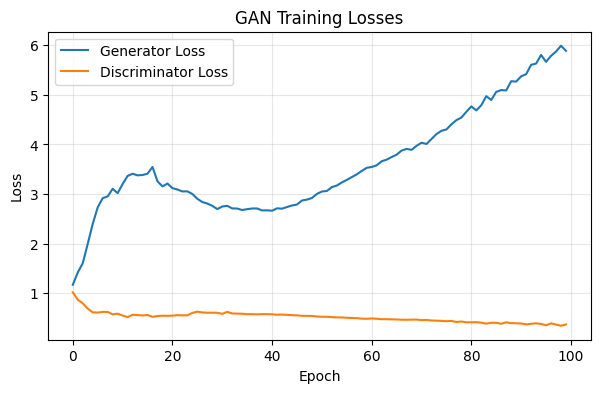

In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(g_losses, label="Generator Loss")
plt.plot(d_losses, label="Discriminator Loss")
plt.title("GAN Training Losses")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("gan_losses.png")
plt.show()

In [ ]:
Gen.eval()

num_fake_samples = min(1000, X_tensor.shape[0])

with torch.no_grad():
    z = torch.randn(num_fake_samples, z_dim).to(device)
    fake_scaled = Gen(z).cpu().numpy()

fake_original_scale = scaler.inverse_transform(fake_scaled)

fake_df = pd.DataFrame(fake_original_scale, columns=X.columns)

print("Generated synthetic traffic shape:", fake_df.shape)
fake_df.head()

Generated synthetic traffic shape: (1000, 78)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
0,112.066559,779838.1875,-0.075316,0.927961,51.620441,-1389.711914,49.497166,50.831123,51.615765,-1.099434,...,-0.586066,20.009439,-2705.287598,42.040916,-9994.253906,-2263.708496,170186.109375,-6628.481445,94120.726562,201904.453125
1,2.360013,173888.1875,2.662999,1.941268,91.118088,-1082.069336,32.964924,30.216583,30.488531,-0.737488,...,0.808222,23.784693,-819.537598,-633.650513,-2254.488037,471.268005,-122359.890625,-17026.701172,-73777.273438,-65497.550781
2,-5.495944,158204.1875,0.688854,1.024587,72.157364,-2618.375977,51.484165,52.622631,52.288456,-0.134629,...,0.255759,32.243195,-950.998535,-721.224731,-2553.722412,-934.696838,-179703.890625,-9600.825195,-202515.281250,-30659.552734
3,-2.389987,200574.1875,1.866750,1.579263,111.769028,-1791.756836,46.010487,40.530239,39.989071,-0.378151,...,2.112809,19.802078,141.321793,1041.126831,-616.675537,-200.942932,222950.109375,-729.231628,216494.718750,64188.449219
4,173.289703,262708.1875,3.327891,-0.978395,29.899279,3096.876953,-4.870295,2.016569,2.885970,2.299690,...,1.878039,19.931650,-7059.928223,2855.521484,-6266.831543,-5180.313965,386522.125000,-10726.700195,-415517.281250,-135371.546875


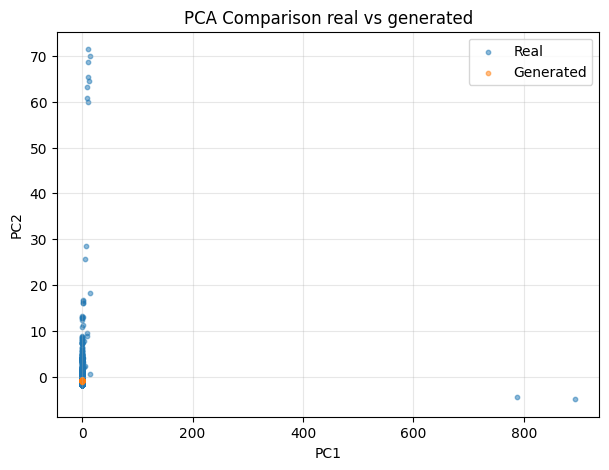

variance ratio: [0.91047088 0.02756872]


In [ ]:
# Using equal number of samples for comparison
num_size = min(1000, X_scaled.shape[0], fake_scaled.shape[0])

real_sam = X_scaled[:num_size]
fake_sam = fake_scaled[:num_size]

combined_sample = np.vstack([real_sam, fake_sam])

pca = PCA(n_components=2)
combined_pca = pca.fit_transform(combined_sample)

real_pca = combined_pca[:num_size]
fake_pca = combined_pca[num_size:]

plt.figure(figsize=(7, 5))
plt.scatter(real_pca[:, 0], real_pca[:, 1], s=10, alpha=0.5, label="Real")
plt.scatter(fake_pca[:, 0], fake_pca[:, 1], s=10, alpha=0.5, label="Generated")
plt.title("PCA Comparison real vs generated")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("variance ratio:", pca.explained_variance_ratio_)

In [ ]:
real_feature = pd.DataFrame(real_sam, columns=X.columns)
fake_feature = pd.DataFrame(fake_sam, columns=X.columns)

# Calculate average diff in feature statistics
mean_difference = (real_feature.mean() - fake_feature.mean()).abs().mean()
std_difference = (real_feature.std() - fake_feature.std()).abs().std()

print(f"Mean difference across features: {mean_difference:.4f}")
print(f"Standard deviation difference across features: {std_difference:.4f}")

Mean difference across features: 0.4313
Standard deviation difference across features: 3.7091


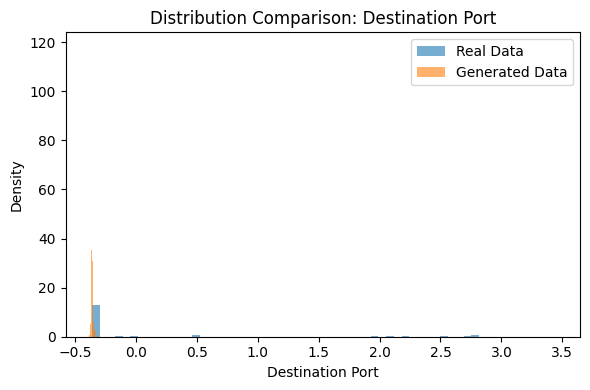

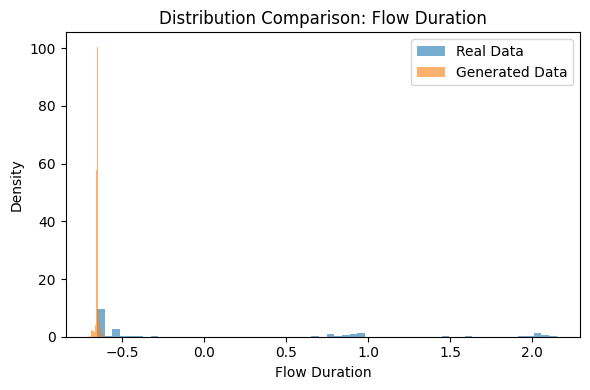

In [ ]:
features_to_plot = X.columns[:2]

for column in features_to_plot:
    plt.figure(figsize=(6, 4))
    plt.hist(real_feature[column], bins=60, density=True, alpha=0.6, label="Real Data")
    plt.hist(fake_feature[column], bins=60, density=True, alpha=0.6, label="Generated Data")
    plt.title(f"Distribution Comparison: {column}")
    plt.xlabel(column)
    plt.ylabel("Density")
    plt.legend()
    plt.tight_layout()
    plt.savefig("dist(2.2).png")
    plt.show()